Saved subset files:
 - uk_active_nodes_subset.csv
 - uk_active_edges_subset.csv
Saved Gephi files:
 - gephi_nodes.csv
 - gephi_edges.csv

--- Subset summary (after filtering) ---
Customer nodes: 200
Product nodes : 2203
Total nodes   : 2403
Edges         : 38538
Weighted?     : Yes (weight_invoices / weight_qty / weight_spend). Unweighted = presence of edge.

--- Degree stats ---
Customers: min/median/mean/max = 9 144.0 192.69 1511
Products : min/median/mean/max = 5 13.0 17.493418066273264 94


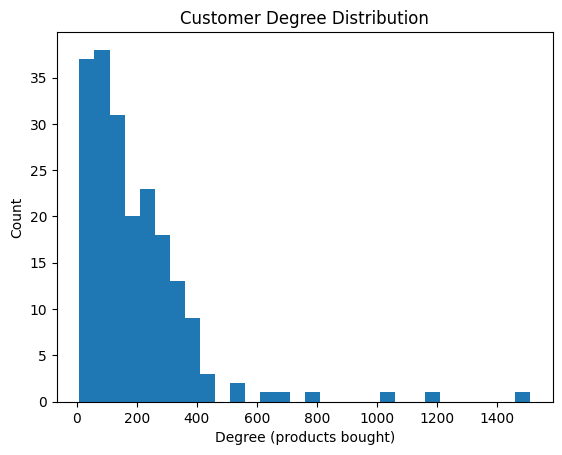

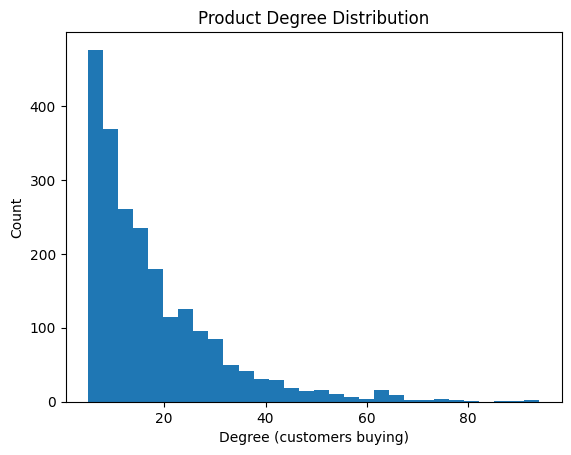


--- Bipartite clustering (square clustering) ---
Avg clustering (customers): 0.06045168932965229
Avg clustering (products) : 0.09646124273089142


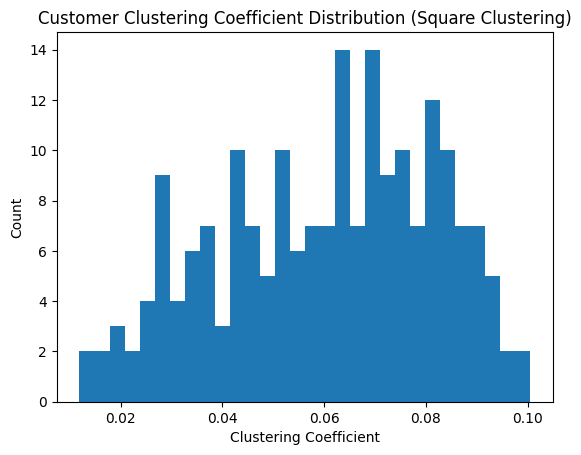

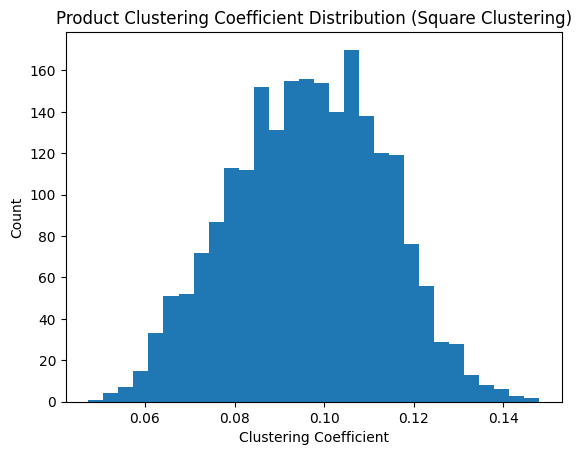


--- Modularity on customer projection ---
Customer-projection nodes: 200
Customer-projection edges: 19072
Number of communities    : 3
Modularity Q             : 0.0380001531143061


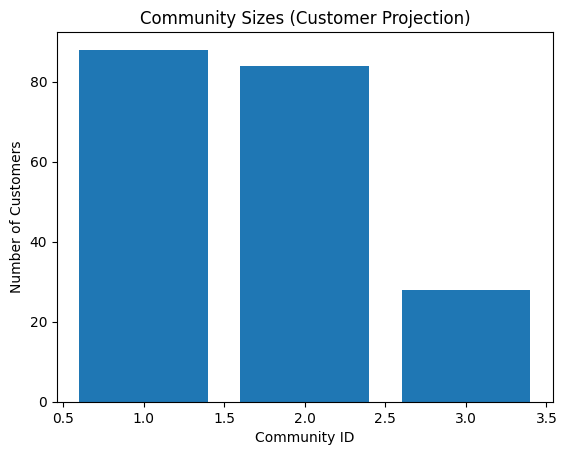


--- Top 10 Betweenness Centrality ---
Customers:
C_12748 0.20364710097710062
C_17841 0.10589817321064439
C_14096 0.0831247353477795
C_14298 0.05046263063806925
C_14606 0.04313107959239128
C_13089 0.02755526693425339
C_15311 0.022625168326895987
C_16033 0.017172496666552888
C_15555 0.015856976412266716
C_17511 0.01430229036387595

Products:
P_85099B 0.001703961826158066
P_22423 0.001659955615594779
P_21212 0.0016588807332012575
P_23203 0.0013973655818805147
P_22720 0.0013943650691262872
P_47566 0.0013654100921338392
P_85123A 0.0013430476603972464
P_20725 0.0012774007827848753
P_22382 0.0012075576958985033
P_23201 0.0011811244819793286


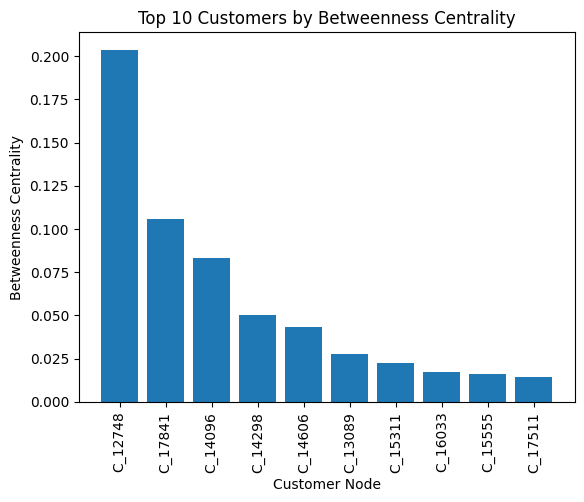

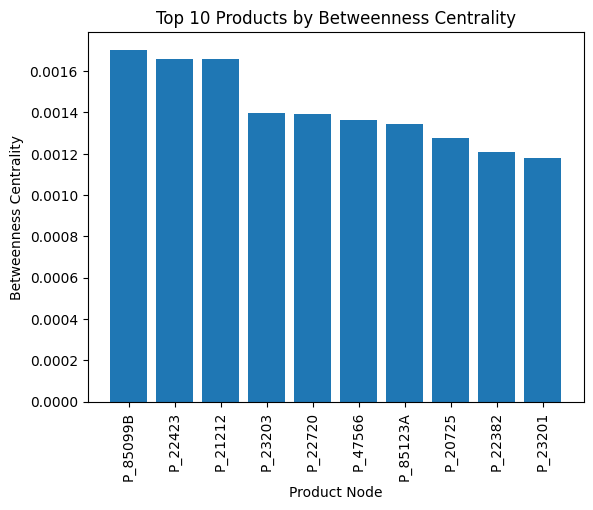

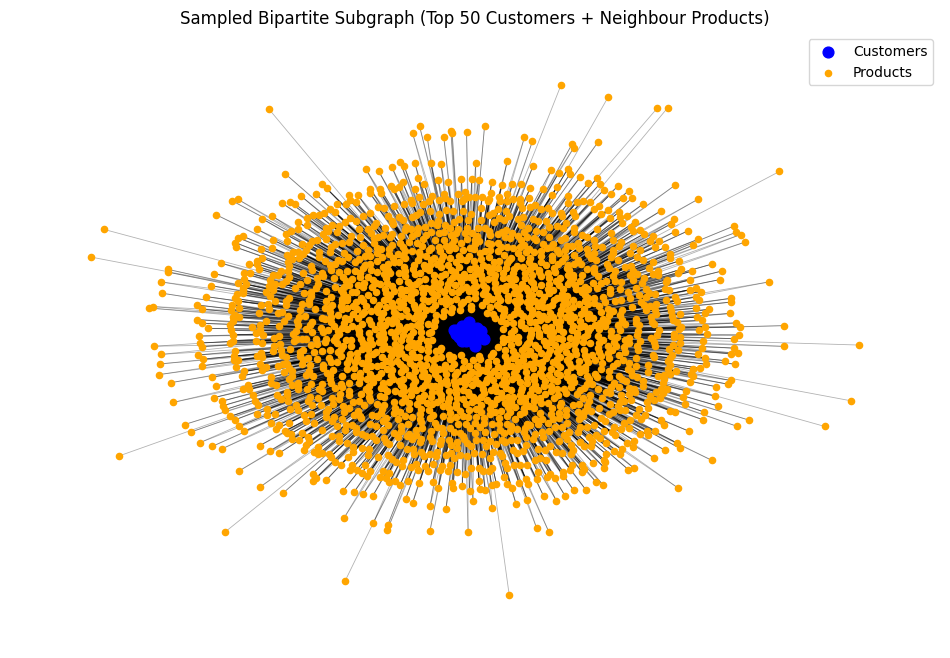

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite
from networkx.algorithms.community import greedy_modularity_communities, modularity
import matplotlib.pyplot as plt

# Config
DATA_PATH = "Online Retail.xlsx"
K = 5  #
TOP_N_CUSTOMERS = 200

# Loading and Cleaning
df = pd.read_excel(DATA_PATH)

# keeping only required columns
needed_cols = ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID", "Country"]
df = df[needed_cols]

# dropping missing customer IDs and duplicates
df = df.dropna(subset=["CustomerID"]).drop_duplicates()

# types
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["StockCode"] = df["StockCode"].astype(str)

# filter for UK
df = df[df["Country"] == "United Kingdom"].copy()

# remove cancellations / returns / invalid lines
df = df[df["Quantity"] > 0].copy()
df = df[df["UnitPrice"] > 0].copy()
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()

# Constrained subset rules
active_customers = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(TOP_N_CUSTOMERS)
      .index
)

df_sub = df[df["CustomerID"].isin(active_customers)].copy()

# keep products purchased by at least K different customers
popular_products = (
    df_sub.groupby("StockCode")["CustomerID"]
          .nunique()
)

popular_products = popular_products[popular_products >= K].index
df_sub = df_sub[df_sub["StockCode"].isin(popular_products)].copy()

# Building edges with weights
df_sub["LineSpend"] = df_sub["Quantity"] * df_sub["UnitPrice"]

edges_df = (
    df_sub.groupby(["CustomerID", "StockCode"])
          .agg(
              weight_invoices=("InvoiceNo", "nunique"),
              weight_qty=("Quantity", "sum"),
              weight_spend=("LineSpend", "sum"),
          )
          .reset_index()
)

# prefix IDs
edges_df["customer_node"] = "C_" + edges_df["CustomerID"]
edges_df["product_node"]  = "P_" + edges_df["StockCode"]

# Creating Nodes and Edges CSVs
customer_nodes = pd.DataFrame({
    "node_id": sorted(edges_df["customer_node"].unique()),
    "node_type": "customer"
})

product_nodes = pd.DataFrame({
    "node_id": sorted(edges_df["product_node"].unique()),
    "node_type": "product"
})

nodes_df = pd.concat([customer_nodes, product_nodes], ignore_index=True)

# Edges file
edges_out = edges_df[[
    "customer_node", "product_node", "weight_invoices", "weight_qty", "weight_spend"
]].rename(columns={
    "customer_node": "customer_id",
    "product_node": "stockcode"
})

nodes_path = "uk_active_nodes_subset.csv"
edges_path = "uk_active_edges_subset.csv"

nodes_df.to_csv(nodes_path, index=False)
edges_out.to_csv(edges_path, index=False)

print("Saved subset files:")
print(" -", nodes_path)
print(" -", edges_path)

# saving Gephi friendly files
gephi_nodes_path = "gephi_nodes.csv"
gephi_edges_path = "gephi_edges.csv"

nodes_df.to_csv(gephi_nodes_path, index=False)
edges_out.rename(columns={"customer_id": "Source", "stockcode": "Target"}).to_csv(gephi_edges_path, index=False)

print("Saved Gephi files:")
print(" -", gephi_nodes_path)
print(" -", gephi_edges_path)

# Building Bipartite Graph in NetworkX
B = nx.Graph()

B.add_nodes_from(customer_nodes["node_id"], bipartite=0, node_type="customer")
B.add_nodes_from(product_nodes["node_id"],  bipartite=1, node_type="product")

# adding edges
for _, r in edges_df.iterrows():
    B.add_edge(
        r["customer_node"],
        r["product_node"],
        weight_invoices=int(r["weight_invoices"]),
        weight_qty=float(r["weight_qty"]),
        weight_spend=float(r["weight_spend"]),
    )

customers = set(customer_nodes["node_id"])
products  = set(product_nodes["node_id"])

print("\n--- Subset summary (after filtering) ---")
print("Customer nodes:", len(customers))
print("Product nodes :", len(products))
print("Total nodes   :", B.number_of_nodes())
print("Edges         :", B.number_of_edges())
print("Weighted?     : Yes (weight_invoices / weight_qty / weight_spend). Unweighted = presence of edge.")

# Degree statistics
deg_all = dict(B.degree())

cust_deg = np.array([deg_all[n] for n in customers])
prod_deg = np.array([deg_all[n] for n in products])

print("\n--- Degree stats ---")
print("Customers: min/median/mean/max =", cust_deg.min(), np.median(cust_deg), cust_deg.mean(), cust_deg.max())
print("Products : min/median/mean/max =", prod_deg.min(), np.median(prod_deg), prod_deg.mean(), prod_deg.max())


# Degree distribution VISUALISATION
plt.figure()
plt.hist(cust_deg, bins=30)
plt.title("Customer Degree Distribution")
plt.xlabel("Degree (products bought)")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(prod_deg, bins=30)
plt.title("Product Degree Distribution")
plt.xlabel("Degree (customers buying)")
plt.ylabel("Count")
plt.show()

# Clustering coefficient
cust_clust = bipartite.cluster.clustering(B, customers)
prod_clust = bipartite.cluster.clustering(B, products)

avg_cust_clust = float(np.mean(list(cust_clust.values()))) if cust_clust else 0.0
avg_prod_clust = float(np.mean(list(prod_clust.values()))) if prod_clust else 0.0

print("\n--- Bipartite clustering (square clustering) ---")
print("Avg clustering (customers):", avg_cust_clust)
print("Avg clustering (products) :", avg_prod_clust)


# Clustering coefficient VISUALISATION (NEW)
plt.figure()
plt.hist(list(cust_clust.values()), bins=30)
plt.title("Customer Clustering Coefficient Distribution (Square Clustering)")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(list(prod_clust.values()), bins=30)
plt.title("Product Clustering Coefficient Distribution (Square Clustering)")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Count")
plt.show()

# Modularity via projection
G_cust = bipartite.weighted_projected_graph(B, customers)

communities = list(greedy_modularity_communities(G_cust, weight="weight"))
Q = modularity(G_cust, communities, weight="weight")

print("\n--- Modularity on customer projection ---")
print("Customer-projection nodes:", G_cust.number_of_nodes())
print("Customer-projection edges:", G_cust.number_of_edges())
print("Number of communities    :", len(communities))
print("Modularity Q             :", Q)

# Modularity / community VISUALISATION (NEW)
community_sizes = [len(c) for c in communities]

plt.figure()
plt.bar(range(1, len(community_sizes) + 1), community_sizes)
plt.title("Community Sizes (Customer Projection)")
plt.xlabel("Community ID")
plt.ylabel("Number of Customers")
plt.show()

# Betweenness centrality
k_samples = min(200, B.number_of_nodes())
bc = nx.betweenness_centrality(B, k=k_samples, seed=42, normalized=True)

top_cust_bc = sorted(((n, v) for n, v in bc.items() if n in customers), key=lambda x: x[1], reverse=True)[:10]
top_prod_bc = sorted(((n, v) for n, v in bc.items() if n in products),  key=lambda x: x[1], reverse=True)[:10]

print("\n--- Top 10 Betweenness Centrality ---")

print("Customers:")
for n, v in top_cust_bc:
    print(n, v)

print("\nProducts:")
for n, v in top_prod_bc:
    print(n, v)

# Betweenness centrality VISUALISATION
plt.figure()
plt.bar([n for n, _ in top_cust_bc], [v for _, v in top_cust_bc])
plt.title("Top 10 Customers by Betweenness Centrality")
plt.xlabel("Customer Node")
plt.ylabel("Betweenness Centrality")
plt.xticks(rotation=90)
plt.show()

plt.figure()
plt.bar([n for n, _ in top_prod_bc], [v for _, v in top_prod_bc])
plt.title("Top 10 Products by Betweenness Centrality")
plt.xlabel("Product Node")
plt.ylabel("Betweenness Centrality")
plt.xticks(rotation=90)
plt.show()

# NetworkX visualisation
top_cust = sorted(customers, key=lambda n: deg_all[n], reverse=True)[:50]

nbr_products = set()
for c in top_cust:
    nbr_products.update(B.neighbors(c))

H_nodes = set(top_cust).union(nbr_products)
H = B.subgraph(H_nodes).copy()

pos = nx.spring_layout(H, seed=42, k=0.25)

plt.figure(figsize=(12, 8))

nx.draw_networkx_edges(H, pos, alpha=0.3, width=0.6)

# customers
nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=top_cust,
    node_size=60,
    node_color="blue",
    label="Customers"
)

# products
nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=list(nbr_products),
    node_size=20,
    node_color="orange",
    label="Products"
)

plt.title("Sampled Bipartite Subgraph (Top 50 Customers + Neighbour Products)")
plt.axis("off")
plt.legend()
plt.show()

task 2


PRODUCT-PRODUCT NETWORK
Product nodes : 2203
Edges         : 2123556
Edge weight meaning: number of shared customers

COMMUNITY DETECTION (LOUVAIN)
Number of communities: 4
Modularity Q         : 0.0537

Community sizes:
Community 1: 690 products
Community 2: 636 products
Community 3: 571 products
Community 4: 306 products

EXAMPLE PRODUCT COMMUNITIES

Community 1 (size = 690):
20971 -> PINK BLUE FELT CRAFT TRINKET BOX
15056N -> EDWARDIAN PARASOL NATURAL
21122 -> SET/10 PINK POLKADOT PARTY CANDLES
22570 -> FELTCRAFT CUSHION RABBIT
21231 -> SWEETHEART CERAMIC TRINKET BOX
22568 -> FELTCRAFT CUSHION OWL
22569 -> FELTCRAFT CUSHION BUTTERFLY
21239 -> PINK  POLKADOT CUP
21154 -> RED RETROSPOT OVEN GLOVE 
20676 -> RED RETROSPOT BOWL

Community 2 (size = 636):
22998 -> TRAVEL CARD WALLET KEEP CALM
21172 -> PARTY METAL SIGN 
22113 -> GREY HEART HOT WATER BOTTLE
84596B -> SMALL DOLLY MIX DESIGN ORANGE BOWL
21232 -> STRAWBERRY CERAMIC TRINKET BOX
22577 -> WOODEN HEART CHRISTMAS SCANDINAVIAN
8459

/tmp/ipykernel_7095/2155568235.py:122: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(prod_communities))


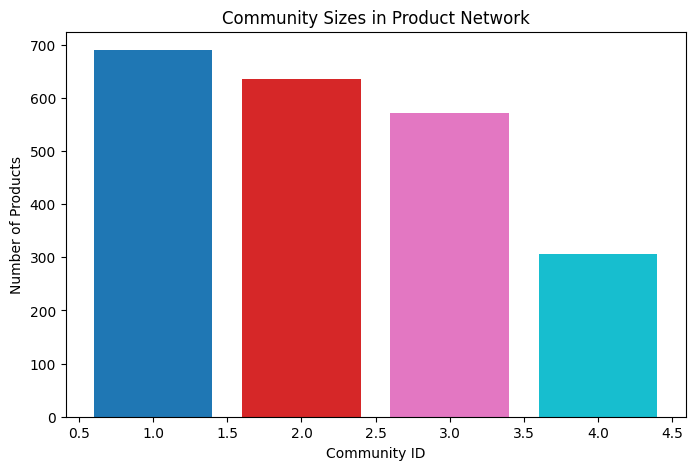

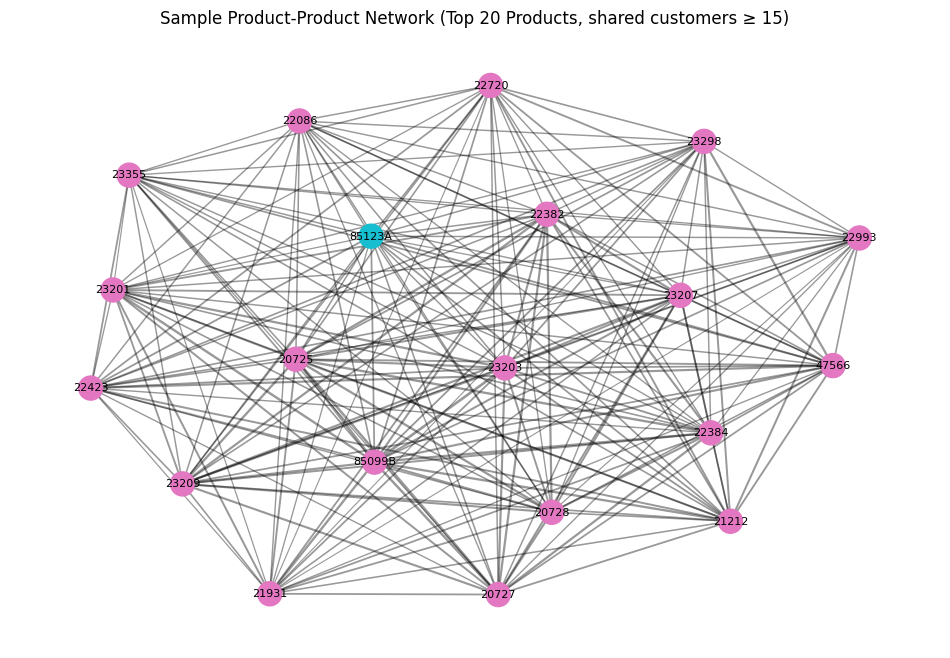

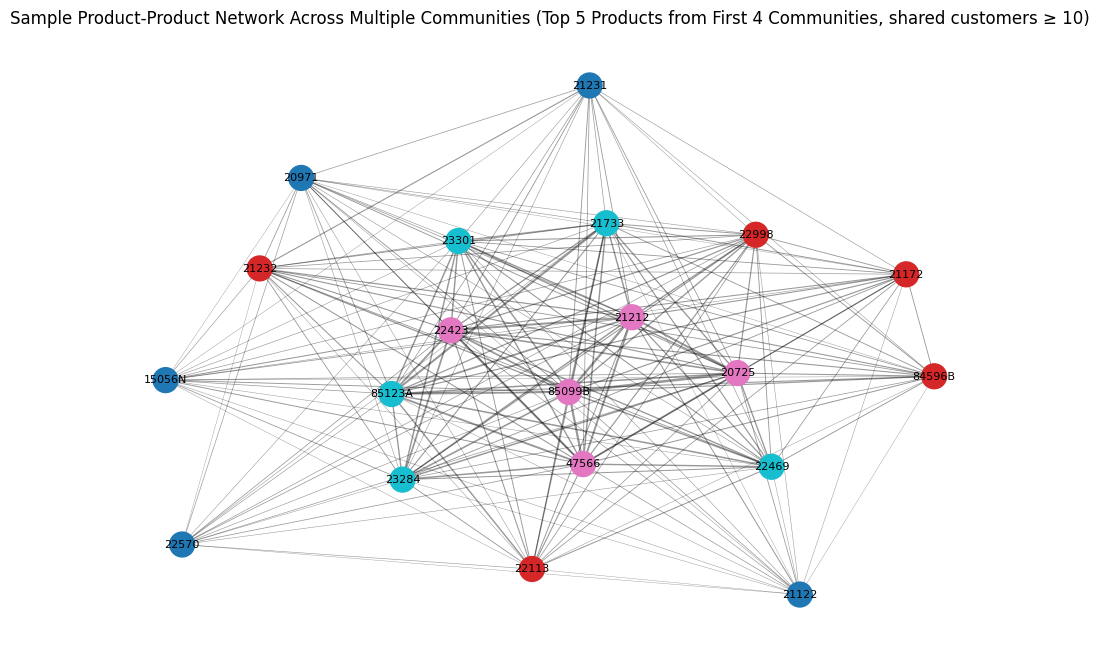

In [ ]:
# =========================
# Task 2: Product Network and Community Detection
# =========================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite
from networkx.algorithms.community import louvain_communities, modularity

# -------------------------
# (a) Create Product-Product Network
# -------------------------
# Two products are connected if at least one customer bought both.
# Edge weight = number of shared customers.
G_prod = bipartite.weighted_projected_graph(B, products)

print("\n==============================")
print("PRODUCT-PRODUCT NETWORK")
print("==============================")
print("Product nodes :", G_prod.number_of_nodes())
print("Edges         :", G_prod.number_of_edges())
print("Edge weight meaning: number of shared customers")

# -------------------------
# (b) Community Detection using Louvain
# -------------------------
prod_communities = list(louvain_communities(G_prod, weight="weight", seed=42))
prod_communities = sorted(prod_communities, key=len, reverse=True)

Q_prod = modularity(G_prod, prod_communities, weight="weight")

print("\n==============================")
print("COMMUNITY DETECTION (LOUVAIN)")
print("==============================")
print("Number of communities:", len(prod_communities))
print("Modularity Q         :", round(Q_prod, 4))

community_sizes = [len(c) for c in prod_communities]

print("\nCommunity sizes:")
for i, size in enumerate(community_sizes, start=1):
    print(f"Community {i}: {size} products")

# -------------------------
# Map StockCode to Description
# -------------------------
product_desc_df = (
    df_sub.groupby("StockCode")["Description"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)

stockcode_to_desc = dict(zip(product_desc_df["StockCode"], product_desc_df["Description"]))

def get_description(product_node):
    stock_code = product_node.replace("P_", "")
    return stockcode_to_desc.get(stock_code, "Unknown")

# -------------------------
# (c) Show Example Products from Communities
# -------------------------
print("\n==============================")
print("EXAMPLE PRODUCT COMMUNITIES")
print("==============================")

TOP_COMMUNITIES_TO_SHOW = min(5, len(prod_communities))

for i, comm in enumerate(prod_communities[:TOP_COMMUNITIES_TO_SHOW], start=1):
    print(f"\nCommunity {i} (size = {len(comm)}):")

    top_products = sorted(
        list(comm),
        key=lambda x: G_prod.degree(x, weight="weight"),
        reverse=True
    )[:10]

    for p in top_products:
        print(f"{p.replace('P_', '')} -> {get_description(p)}")

# -------------------------
# Save Community Assignments
# -------------------------
community_rows = []
for comm_id, comm in enumerate(prod_communities, start=1):
    for p in comm:
        community_rows.append({
            "product_node": p,
            "stockcode": p.replace("P_", ""),
            "description": get_description(p),
            "community_id": comm_id
        })

community_df = pd.DataFrame(community_rows)
community_df.to_csv("product_communities_louvain.csv", index=False)

print("\nSaved: product_communities_louvain.csv")

# -------------------------
# Save Product-Product Edge List
# -------------------------
prod_edges_rows = []
for u, v, d in G_prod.edges(data=True):
    prod_edges_rows.append({
        "source_product": u,
        "target_product": v,
        "source_stockcode": u.replace("P_", ""),
        "target_stockcode": v.replace("P_", ""),
        "shared_customers": d["weight"]
    })

prod_edges_df = pd.DataFrame(prod_edges_rows)
prod_edges_df.to_csv("product_product_edges.csv", index=False)

print("Saved: product_product_edges.csv")

# -------------------------
# Community Colors
# -------------------------
# Assign a color to each community
cmap = plt.cm.get_cmap("tab10", len(prod_communities))
community_color_map = {}

for i, comm in enumerate(prod_communities):
    for node in comm:
        community_color_map[node] = cmap(i)

# -------------------------
# Bar Graph: Community Sizes
# -------------------------
plt.figure(figsize=(8, 5))
bar_colors = [cmap(i) for i in range(len(community_sizes))]
plt.bar(range(1, len(community_sizes) + 1), community_sizes, color=bar_colors)
plt.title("Community Sizes in Product Network")
plt.xlabel("Community ID")
plt.ylabel("Number of Products")
plt.show()

# -------------------------
# Sample Product Network Visualisation
# -------------------------
# Use top products by weighted degree for a readable sample graph
top_products = [
    n for n, _ in sorted(G_prod.degree(weight="weight"), key=lambda x: x[1], reverse=True)[:20]
]

H_prod = G_prod.subgraph(top_products).copy()

# Keep only stronger edges so the graph does not become too dense
MIN_SHARED_CUSTOMERS = 15

strong_edges = [
    (u, v) for u, v, d in H_prod.edges(data=True)
    if d.get("weight", 0) >= MIN_SHARED_CUSTOMERS
]

H_vis = nx.Graph()
H_vis.add_nodes_from(H_prod.nodes(data=True))
H_vis.add_edges_from((u, v, H_prod[u][v]) for u, v in strong_edges)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(H_vis, seed=42, k=0.8)

# Edge widths based on shared customers
edge_widths = [H_vis[u][v]["weight"] * 0.03 for u, v in H_vis.edges()]

# Node colors based on community
node_colors = [community_color_map.get(n, "gray") for n in H_vis.nodes()]

nx.draw_networkx_edges(H_vis, pos, alpha=0.4, width=edge_widths)
nx.draw_networkx_nodes(H_vis, pos, node_size=300, node_color=node_colors)
nx.draw_networkx_labels(
    H_vis,
    pos,
    labels={n: n.replace("P_", "") for n in H_vis.nodes()},
    font_size=8
)

plt.title(f"Sample Product-Product Network (Top 20 Products, shared customers ≥ {MIN_SHARED_CUSTOMERS})")
plt.axis("off")
plt.show()

# -------------------------
# Second Sample Graph:
# Products selected from multiple communities
# -------------------------
sample_nodes_multi = []

NUM_COMMUNITIES_TO_SHOW = min(4, len(prod_communities))
TOP_PER_COMMUNITY = 5

for comm in prod_communities[:NUM_COMMUNITIES_TO_SHOW]:
    top_in_comm = sorted(
        list(comm),
        key=lambda x: G_prod.degree(x, weight="weight"),
        reverse=True
    )[:TOP_PER_COMMUNITY]
    sample_nodes_multi.extend(top_in_comm)

# remove duplicates while preserving order
sample_nodes_multi = list(dict.fromkeys(sample_nodes_multi))

H_prod_multi = G_prod.subgraph(sample_nodes_multi).copy()

MIN_SHARED_CUSTOMERS_MULTI = 10

strong_edges_multi = [
    (u, v) for u, v, d in H_prod_multi.edges(data=True)
    if d.get("weight", 0) >= MIN_SHARED_CUSTOMERS_MULTI
]

H_vis_multi = nx.Graph()
H_vis_multi.add_nodes_from(H_prod_multi.nodes(data=True))
H_vis_multi.add_edges_from((u, v, H_prod_multi[u][v]) for u, v in strong_edges_multi)

plt.figure(figsize=(12, 8))
pos_multi = nx.spring_layout(H_vis_multi, seed=42, k=0.9)

edge_widths_multi = [H_vis_multi[u][v]["weight"] * 0.03 for u, v in H_vis_multi.edges()]
node_colors_multi = [community_color_map.get(n, "gray") for n in H_vis_multi.nodes()]

nx.draw_networkx_edges(H_vis_multi, pos_multi, alpha=0.4, width=edge_widths_multi)
nx.draw_networkx_nodes(H_vis_multi, pos_multi, node_size=320, node_color=node_colors_multi)
nx.draw_networkx_labels(
    H_vis_multi,
    pos_multi,
    labels={n: n.replace("P_", "") for n in H_vis_multi.nodes()},
    font_size=8
)

plt.title(
    f"Sample Product-Product Network Across Multiple Communities "
    f"(Top {TOP_PER_COMMUNITY} Products from First {NUM_COMMUNITIES_TO_SHOW} Communities, "
    f"shared customers ≥ {MIN_SHARED_CUSTOMERS_MULTI})"
)
plt.axis("off")
plt.show()

task 3


TASK 3: RECOMMENDATION SETUP
Customers: 200
Products : 2203
Customers used for evaluation: 200

--- Training Product Network ---
Nodes: 2203
Edges: 2120967

RECOMMENDATION COMPARISON
                    Method  HitRate@10    MRR@10  Diversity  \
0                 PageRank       0.065  0.029984   0.620728   
1  Collaborative Filtering       0.100  0.057798   0.672353   

                                    Interpretability  
0  High: based on network centrality and product ...  
1  Moderate: based on similarity to previously pu...  
Saved: task3_recommendation_comparison.csv

SAMPLE RECOMMENDATIONS

Customer: 12748
Held-out product: SET 6 FOOTBALL CELEBRATION CANDLES

PageRank recommendations:
  22178 -> VICTORIAN GLASS HANGING T-LIGHT
  21671 -> RED SPOT CERAMIC DRAWER KNOB
  48194 -> DOORMAT HEARTS
  82484 -> WOOD BLACK BOARD ANT WHITE FINISH
  22652 -> TRAVEL SEWING KIT

Collaborative filtering recommendations:
  22413 -> METAL SIGN TAKE IT OR LEAVE IT 
  20676 -> RED RETROSPOT BOWL

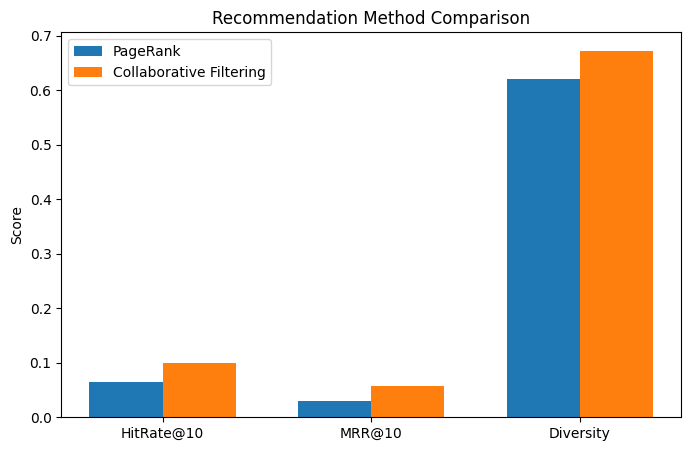

In [ ]:
# =========================
# Task 3: Graph-based Recommendation and Comparison
# =========================

import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite
from collections import defaultdict
from itertools import combinations
import matplotlib.pyplot as plt
import random

# --------------------------------------------------
# 1. Prepare customer-product interaction data
# --------------------------------------------------
# Unique customer-product links
customer_products = edges_df.groupby("CustomerID")["StockCode"].apply(set).to_dict()
all_products = set(edges_df["StockCode"].unique())
all_customers = list(customer_products.keys())

print("\n==============================")
print("TASK 3: RECOMMENDATION SETUP")
print("==============================")
print("Customers:", len(all_customers))
print("Products :", len(all_products))

# --------------------------------------------------
# 2. Train-test split (leave-one-out)
# --------------------------------------------------
random.seed(42)

train_customer_products = {}
test_items = {}

for cust, prods in customer_products.items():
    prods = list(prods)
    if len(prods) >= 2:
        held_out = random.choice(prods)
        train_customer_products[cust] = set(prods) - {held_out}
        test_items[cust] = held_out
    else:
        train_customer_products[cust] = set(prods)

eval_customers = list(test_items.keys())
print("Customers used for evaluation:", len(eval_customers))

# --------------------------------------------------
# 3. Build training bipartite graph
# --------------------------------------------------
B_train = nx.Graph()
customer_nodes = ["C_" + c for c in train_customer_products.keys()]
product_nodes = ["P_" + p for p in all_products]

B_train.add_nodes_from(customer_nodes, bipartite=0, node_type="customer")
B_train.add_nodes_from(product_nodes, bipartite=1, node_type="product")

for cust, prods in train_customer_products.items():
    for p in prods:
        B_train.add_edge("C_" + cust, "P_" + p)

# Product nodes for bipartite projection
products_train = set(product_nodes)

# --------------------------------------------------
# 4. Product-product network
# --------------------------------------------------
G_prod_train = bipartite.weighted_projected_graph(B_train, products_train)

print("\n--- Training Product Network ---")
print("Nodes:", G_prod_train.number_of_nodes())
print("Edges:", G_prod_train.number_of_edges())

# --------------------------------------------------
# 5. Product descriptions
# --------------------------------------------------
product_desc_df = (
    df_sub.groupby("StockCode")["Description"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)
stockcode_to_desc = dict(zip(product_desc_df["StockCode"], product_desc_df["Description"]))

def describe_product(code):
    return stockcode_to_desc.get(code, "Unknown")

# --------------------------------------------------
# 6. Global PageRank on product network
# --------------------------------------------------
pagerank_scores = nx.pagerank(G_prod_train, weight="weight")

# --------------------------------------------------
# 7. Item-based Collaborative Filtering (Jaccard similarity)
# --------------------------------------------------
product_customers_train = defaultdict(set)
for c, prods in train_customer_products.items():
    for p in prods:
        product_customers_train[p].add(c)

def jaccard_similarity(p1, p2):
    c1, c2 = product_customers_train.get(p1, set()), product_customers_train.get(p2, set())
    union = c1 | c2
    if not union:
        return 0.0
    return len(c1 & c2) / len(union)

# Cache for efficiency
sim_cache = {}
def get_sim(p1, p2):
    key = tuple(sorted((p1, p2)))
    if key not in sim_cache:
        sim_cache[key] = jaccard_similarity(p1, p2)
    return sim_cache[key]

# --------------------------------------------------
# 8. Recommendation functions
# --------------------------------------------------
def recommend_pagerank(customer_id, top_k=10):
    """
    Personalized PageRank recommendation:
    score = edge weight * global PageRank of neighbor
    """
    owned = train_customer_products.get(customer_id, set())
    candidate_scores = defaultdict(float)

    for p in owned:
        node = "P_" + p
        if node in G_prod_train:
            for nbr in G_prod_train.neighbors(node):
                nbr_code = nbr.replace("P_", "")
                if nbr_code not in owned:
                    weight = G_prod_train[node][nbr].get("weight", 1.0)
                    candidate_scores[nbr_code] += weight * pagerank_scores.get(nbr, 0)

    ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
    return [p for p, _ in ranked[:top_k]]

def recommend_cf(customer_id, top_k=10):
    """
    Item-based CF using Jaccard similarity
    """
    owned = train_customer_products.get(customer_id, set())
    candidate_scores = defaultdict(float)

    for p in owned:
        for candidate in all_products:
            if candidate not in owned:
                candidate_scores[candidate] += get_sim(p, candidate)

    ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
    return [p for p, _ in ranked[:top_k]]

# --------------------------------------------------
# 9. Evaluation metrics
# --------------------------------------------------
def list_diversity(rec_list):
    if len(rec_list) < 2:
        return 0.0
    vals = [1 - get_sim(a, b) for a, b in combinations(rec_list, 2)]
    return np.mean(vals)

def evaluate_method(recommender_func, customers_eval, k=10):
    hits, reciprocal_ranks, diversities = 0, [], []
    recommendations = {}

    for cust in customers_eval:
        recs = recommender_func(cust, top_k=k)
        recommendations[cust] = recs
        true_item = test_items[cust]

        # Hit Rate
        if true_item in recs:
            hits += 1
            rank = recs.index(true_item) + 1
            reciprocal_ranks.append(1 / rank)
        else:
            reciprocal_ranks.append(0.0)

        # Diversity
        diversities.append(list_diversity(recs))

    hr = hits / len(customers_eval)
    mrr = np.mean(reciprocal_ranks)
    div = np.mean(diversities)

    return {"HitRate@K": hr, "MRR@K": mrr, "Diversity": div, "recommendations": recommendations}

# --------------------------------------------------
# 10. Run evaluation
# --------------------------------------------------
K = 10

pagerank_results = evaluate_method(recommend_pagerank, eval_customers, k=K)
cf_results = evaluate_method(recommend_cf, eval_customers, k=K)

# --------------------------------------------------
# 11. Comparison table
# --------------------------------------------------
comparison_df = pd.DataFrame({
    "Method": ["PageRank", "Collaborative Filtering"],
    f"HitRate@{K}": [pagerank_results["HitRate@K"], cf_results["HitRate@K"]],
    f"MRR@{K}": [pagerank_results["MRR@K"], cf_results["MRR@K"]],
    "Diversity": [pagerank_results["Diversity"], cf_results["Diversity"]],
    "Interpretability": [
        "High: based on network centrality and product importance",
        "Moderate: based on similarity to previously purchased products"
    ]
})
print("\n==============================")
print("RECOMMENDATION COMPARISON")
print("==============================")
print(comparison_df)

comparison_df.to_csv("task3_recommendation_comparison.csv", index=False)
print("Saved: task3_recommendation_comparison.csv")

# --------------------------------------------------
# 12. Sample recommendations
# --------------------------------------------------
sample_customers = eval_customers[:5]
sample_rows = []

print("\n==============================")
print("SAMPLE RECOMMENDATIONS")
print("==============================")

for cust in sample_customers:
    true_item = test_items[cust]
    pr_recs = pagerank_results["recommendations"][cust]
    cf_recs = cf_results["recommendations"][cust]

    print(f"\nCustomer: {cust}")
    print("Held-out product:", describe_product(true_item))

    print("\nPageRank recommendations:")
    for p in pr_recs[:5]:
        print(" ", p, "->", describe_product(p))

    print("\nCollaborative filtering recommendations:")
    for p in cf_recs[:5]:
        print(" ", p, "->", describe_product(p))

    # Save for CSV
    sample_rows.append({
        "customer": cust,
        "held_out_product": true_item,
        "pagerank_recommendations": ", ".join(pr_recs),
        "collaborative_filtering_recommendations": ", ".join(cf_recs)
    })

sample_recs_df = pd.DataFrame(sample_rows)
sample_recs_df.to_csv("task3_sample_recommendations.csv", index=False)
print("Saved: task3_sample_recommendations.csv")

# --------------------------------------------------
# 13. Plot comparison
# --------------------------------------------------
metrics_to_plot = [f"HitRate@{K}", f"MRR@{K}", "Diversity"]
values_pr = [pagerank_results["HitRate@K"], pagerank_results["MRR@K"], pagerank_results["Diversity"]]
values_cf = [cf_results["HitRate@K"], cf_results["MRR@K"], cf_results["Diversity"]]

x = np.arange(len(metrics_to_plot))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, values_pr, width, label="PageRank")
plt.bar(x + width/2, values_cf, width, label="Collaborative Filtering")
plt.xticks(x, metrics_to_plot)
plt.ylabel("Score")
plt.title("Recommendation Method Comparison")
plt.legend()
plt.show()

task 4


TASK 4: TEMPORAL NETWORK ANALYSIS
Number of monthly periods: 13
Periods: ['2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12']

Saved:
 - task4_monthly_network_stats.csv
 - task4_top_customers_by_month.csv
 - task4_top_products_by_month.csv
 - task4_monthly_community_sizes.csv

MONTHLY NETWORK STATISTICS
      month  customer_nodes  product_nodes  total_nodes  edges  \
0   2010-12             156           1344         1500   5552   
1   2011-01             141           1248         1389   4484   
2   2011-02             145           1243         1388   4489   
3   2011-03             156           1274         1430   5020   
4   2011-04             164           1291         1455   5024   
5   2011-05             180           1314         1494   6001   
6   2011-06             172           1393         1565   5952   
7   2011-07             167           1458         1625   5912   
8   2011-

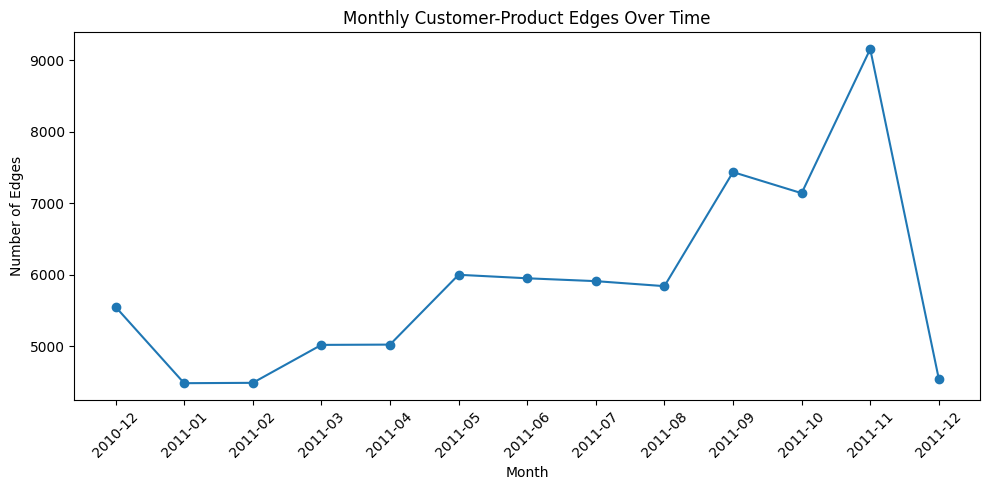

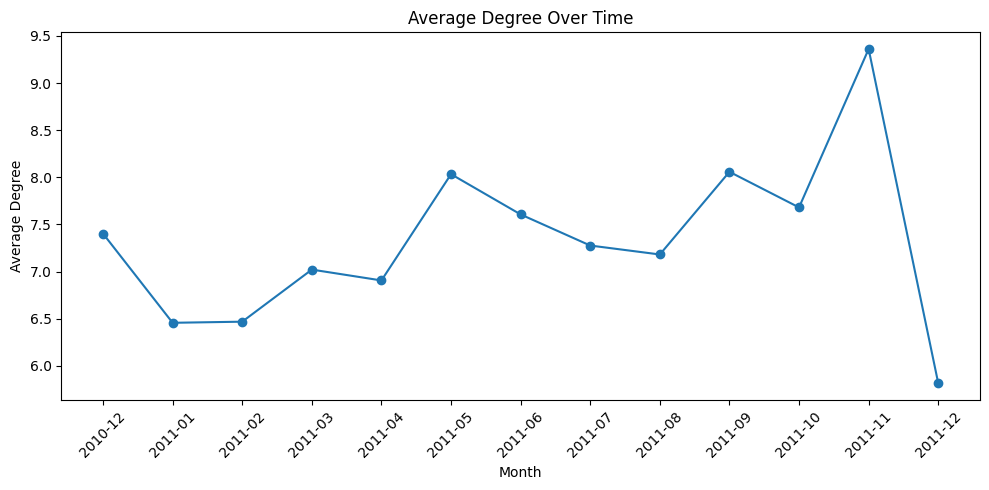

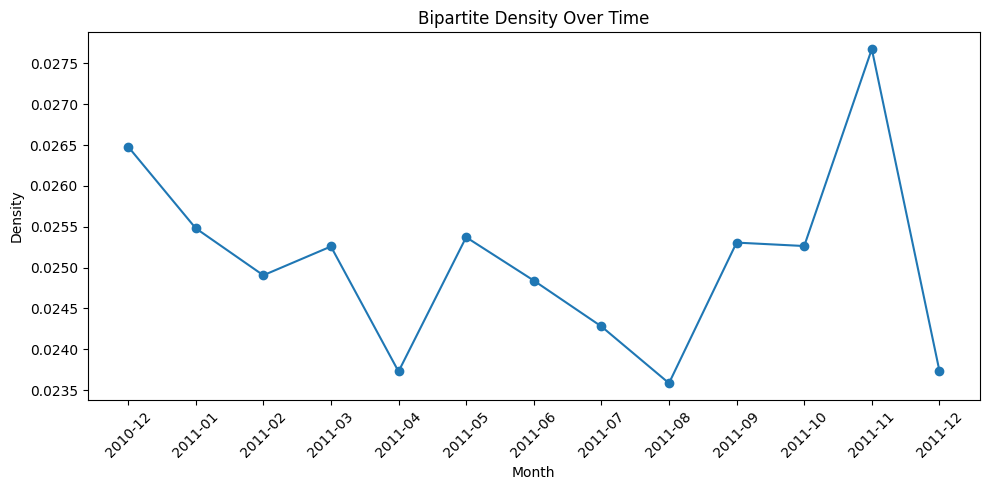

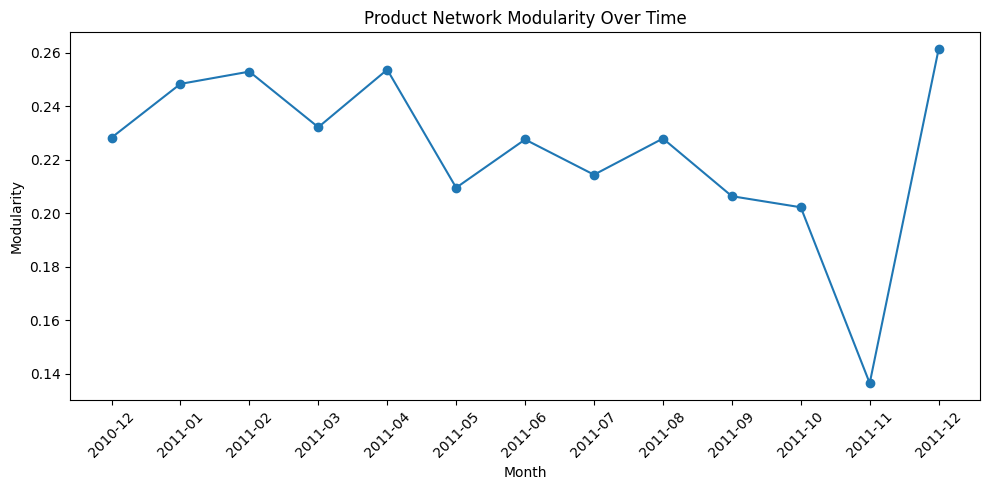

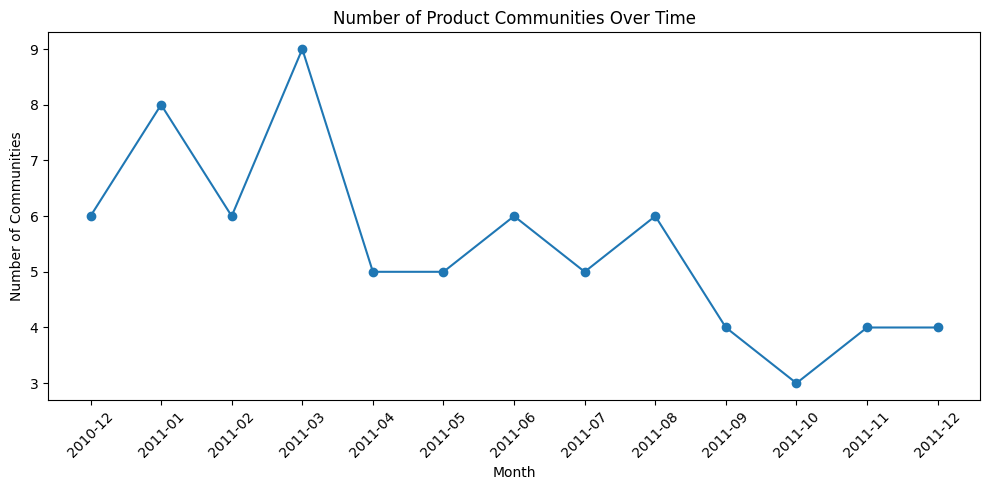

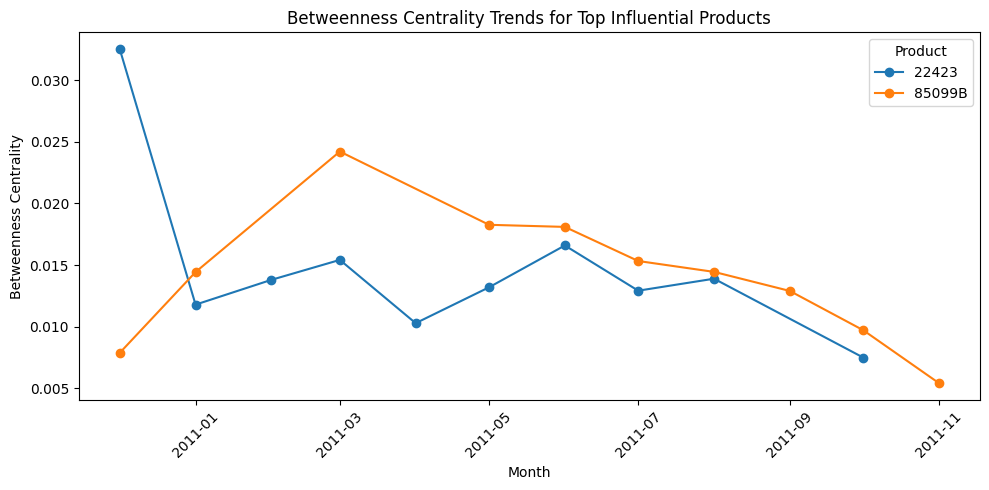

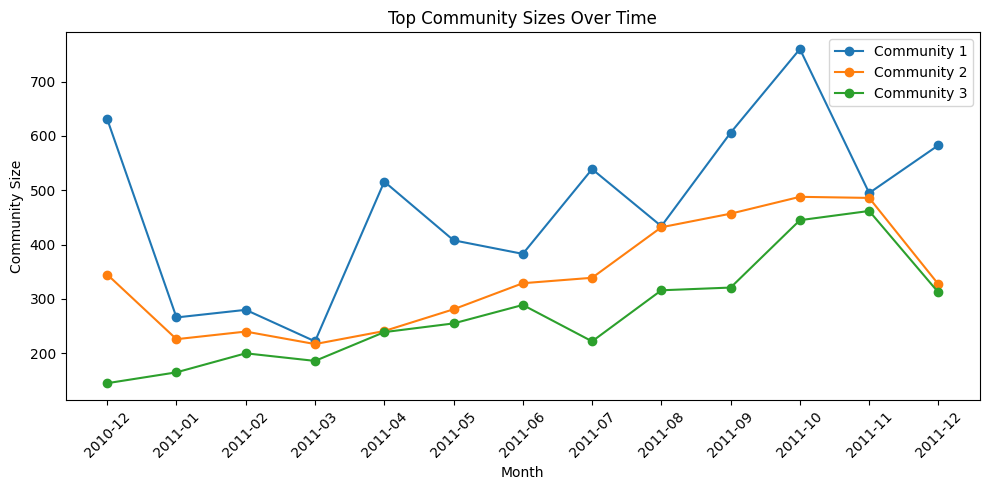

Saved: task4_monthly_sales_summary.csv


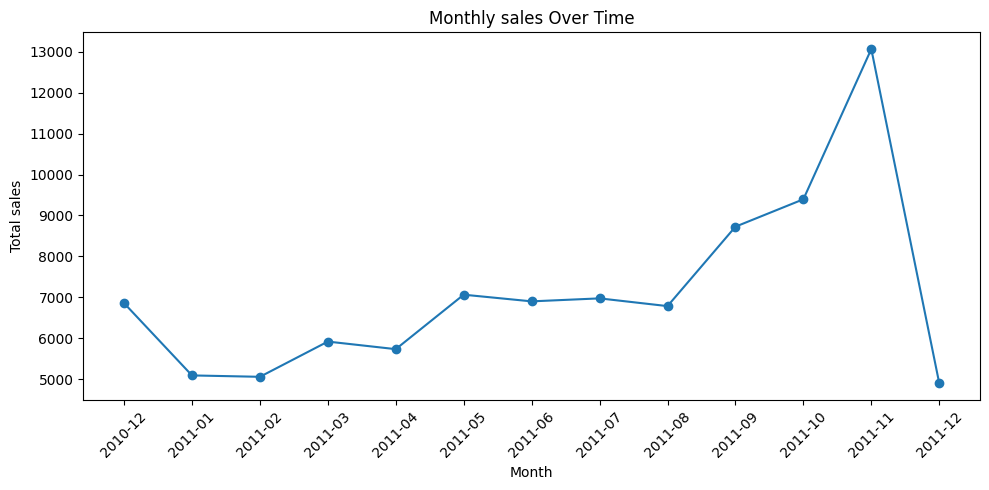

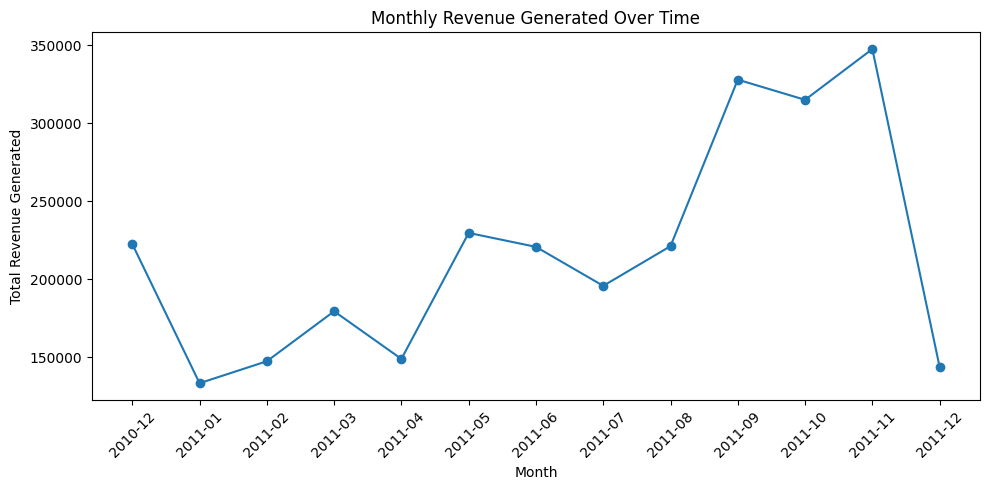

In [ ]:

# Task 4 (PG): Temporal Analysis, Influence Analysis, and Network Change Modelling

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite
from networkx.algorithms.community import louvain_communities, modularity


# 1. Prepare temporal data
df_time = df_sub.copy()
df_time["InvoiceDate"] = pd.to_datetime(df_time["InvoiceDate"])
df_time["YearMonth"] = df_time["InvoiceDate"].dt.to_period("M").astype(str)

monthly_periods = sorted(df_time["YearMonth"].unique())

print("\n==============================")
print("TASK 4: TEMPORAL NETWORK ANALYSIS")
print("==============================")
print("Number of monthly periods:", len(monthly_periods))
print("Periods:", monthly_periods)

# 2. Temporal Analysis: build monthly bipartite graphs
monthly_rows = []
monthly_customer_centrality = []
monthly_product_centrality = []
monthly_community_rows = []

for period in monthly_periods:
    month_df = df_time[df_time["YearMonth"] == period].copy()

    # aggregate monthly customer-product links
    month_edges = (
        month_df.groupby(["CustomerID", "StockCode"])
        .agg(
            weight_invoices=("InvoiceNo", "nunique"),
            weight_qty=("Quantity", "sum"),
            weight_spend=("LineSpend", "sum"),
        )
        .reset_index()
    )

    month_edges["customer_node"] = "C_" + month_edges["CustomerID"].astype(str)
    month_edges["product_node"] = "P_" + month_edges["StockCode"].astype(str)

    month_customers = sorted(month_edges["customer_node"].unique())
    month_products = sorted(month_edges["product_node"].unique())

    # build monthly bipartite graph
    B_month = nx.Graph()
    B_month.add_nodes_from(month_customers, bipartite=0, node_type="customer")
    B_month.add_nodes_from(month_products, bipartite=1, node_type="product")

    for _, r in month_edges.iterrows():
        B_month.add_edge(
            r["customer_node"],
            r["product_node"],
            weight_invoices=int(r["weight_invoices"]),
            weight_qty=float(r["weight_qty"]),
            weight_spend=float(r["weight_spend"]),
        )

    # basic monthly stats
    num_customers = len(month_customers)
    num_products = len(month_products)
    num_nodes = B_month.number_of_nodes()
    num_edges = B_month.number_of_edges()
    density = bipartite.density(B_month, month_customers) if num_customers > 0 and num_products > 0 else 0.0
    avg_degree = np.mean([d for _, d in B_month.degree()]) if num_nodes > 0 else 0.0

    # bipartite clustering (square clustering)
    cust_clust = bipartite.cluster.clustering(B_month, month_customers) if num_customers > 0 else {}
    prod_clust = bipartite.cluster.clustering(B_month, month_products) if num_products > 0 else {}

    avg_cust_clust = float(np.mean(list(cust_clust.values()))) if cust_clust else 0.0
    avg_prod_clust = float(np.mean(list(prod_clust.values()))) if prod_clust else 0.0

    # approximate betweenness centrality for monthly bipartite graph
    if num_nodes > 1 and num_edges > 0:
        k_val = min(100, num_nodes)
        bc_month = nx.betweenness_centrality(B_month, k=k_val, seed=42, normalized=True)
    else:
        bc_month = {n: 0.0 for n in B_month.nodes()}

    # top customers by betweenness
    top_cust_month = sorted(
        [(n, v) for n, v in bc_month.items() if n in month_customers],
        key=lambda x: x[1],
        reverse=True
    )[:10]

    for rank, (node, score) in enumerate(top_cust_month, start=1):
        monthly_customer_centrality.append({
            "month": period,
            "rank": rank,
            "customer_node": node,
            "betweenness": score,
            "degree": B_month.degree(node)
        })

    # top products by betweenness
    top_prod_month = sorted(
        [(n, v) for n, v in bc_month.items() if n in month_products],
        key=lambda x: x[1],
        reverse=True
    )[:10]

    for rank, (node, score) in enumerate(top_prod_month, start=1):
        monthly_product_centrality.append({
            "month": period,
            "rank": rank,
            "product_node": node,
            "stockcode": node.replace("P_", ""),
            "description": stockcode_to_desc.get(node.replace("P_", ""), "Unknown"),
            "betweenness": score,
            "degree": B_month.degree(node)
        })

    # product-product network for community and modularity analysis
    G_prod_month = bipartite.weighted_projected_graph(B_month, month_products)

    if G_prod_month.number_of_nodes() > 0 and G_prod_month.number_of_edges() > 0:
        month_communities = list(louvain_communities(G_prod_month, weight="weight", seed=42))
        month_modularity = modularity(G_prod_month, month_communities, weight="weight")
        num_communities = len(month_communities)
        largest_community_size = max(len(c) for c in month_communities)
        avg_weighted_degree_prod = np.mean([d for _, d in G_prod_month.degree(weight="weight")]) if G_prod_month.number_of_nodes() > 0 else 0.0

        for comm_id, comm in enumerate(sorted(month_communities, key=len, reverse=True), start=1):
            monthly_community_rows.append({
                "month": period,
                "community_id": comm_id,
                "community_size": len(comm)
            })
    else:
        month_modularity = 0.0
        num_communities = 0
        largest_community_size = 0
        avg_weighted_degree_prod = 0.0

    monthly_rows.append({
        "month": period,
        "customer_nodes": num_customers,
        "product_nodes": num_products,
        "total_nodes": num_nodes,
        "edges": num_edges,
        "bipartite_density": density,
        "avg_degree": avg_degree,
        "avg_customer_clustering": avg_cust_clust,
        "avg_product_clustering": avg_prod_clust,
        "product_projection_nodes": G_prod_month.number_of_nodes(),
        "product_projection_edges": G_prod_month.number_of_edges(),
        "avg_weighted_degree_product_network": avg_weighted_degree_prod,
        "num_product_communities": num_communities,
        "largest_product_community_size": largest_community_size,
        "product_network_modularity": month_modularity
    })


# 3. Save temporal results
monthly_stats_df = pd.DataFrame(monthly_rows)
monthly_customer_centrality_df = pd.DataFrame(monthly_customer_centrality)
monthly_product_centrality_df = pd.DataFrame(monthly_product_centrality)
monthly_community_df = pd.DataFrame(monthly_community_rows)

monthly_stats_df.to_csv("task4_monthly_network_stats.csv", index=False)
monthly_customer_centrality_df.to_csv("task4_top_customers_by_month.csv", index=False)
monthly_product_centrality_df.to_csv("task4_top_products_by_month.csv", index=False)
monthly_community_df.to_csv("task4_monthly_community_sizes.csv", index=False)

print("\nSaved:")
print(" - task4_monthly_network_stats.csv")
print(" - task4_top_customers_by_month.csv")
print(" - task4_top_products_by_month.csv")
print(" - task4_monthly_community_sizes.csv")

print("\n==============================")
print("MONTHLY NETWORK STATISTICS")
print("==============================")
print(monthly_stats_df)


# 4. Influence Analysis on full network
print("\n==============================")
print("INFLUENCE ANALYSIS (FULL NETWORK)")
print("==============================")

# weighted degree on bipartite graph using invoice count
weighted_degree_invoices = dict(B.degree(weight="weight_invoices"))

# approximate betweenness on full bipartite graph
k_full = min(200, B.number_of_nodes())
bc_full = nx.betweenness_centrality(B, k=k_full, seed=42, normalized=True)

top_customers_degree = sorted(
    [(n, weighted_degree_invoices.get(n, 0)) for n in customers],
    key=lambda x: x[1],
    reverse=True
)[:10]

top_products_degree = sorted(
    [(n, weighted_degree_invoices.get(n, 0)) for n in products],
    key=lambda x: x[1],
    reverse=True
)[:10]

top_customers_bc = sorted(
    [(n, bc_full.get(n, 0)) for n in customers],
    key=lambda x: x[1],
    reverse=True
)[:10]

top_products_bc = sorted(
    [(n, bc_full.get(n, 0)) for n in products],
    key=lambda x: x[1],
    reverse=True
)[:10]

print("\nTop 10 Customers by Weighted Degree (Invoices):")
for n, v in top_customers_degree:
    print(n, v)

print("\nTop 10 Products by Weighted Degree (Invoices):")
for n, v in top_products_degree:
    print(n, v, "->", stockcode_to_desc.get(n.replace("P_", ""), "Unknown"))

print("\nTop 10 Customers by Betweenness Centrality:")
for n, v in top_customers_bc:
    print(n, v)

print("\nTop 10 Products by Betweenness Centrality:")
for n, v in top_products_bc:
    print(n, v, "->", stockcode_to_desc.get(n.replace("P_", ""), "Unknown"))

# save influence analysis
influence_rows = []

for rank, (n, v) in enumerate(top_customers_degree, start=1):
    influence_rows.append({
        "node_type": "customer",
        "metric": "weighted_degree_invoices",
        "rank": rank,
        "node_id": n,
        "description": "",
        "score": v
    })

for rank, (n, v) in enumerate(top_products_degree, start=1):
    influence_rows.append({
        "node_type": "product",
        "metric": "weighted_degree_invoices",
        "rank": rank,
        "node_id": n,
        "description": stockcode_to_desc.get(n.replace("P_", ""), "Unknown"),
        "score": v
    })

for rank, (n, v) in enumerate(top_customers_bc, start=1):
    influence_rows.append({
        "node_type": "customer",
        "metric": "betweenness_centrality",
        "rank": rank,
        "node_id": n,
        "description": "",
        "score": v
    })

for rank, (n, v) in enumerate(top_products_bc, start=1):
    influence_rows.append({
        "node_type": "product",
        "metric": "betweenness_centrality",
        "rank": rank,
        "node_id": n,
        "description": stockcode_to_desc.get(n.replace("P_", ""), "Unknown"),
        "score": v
    })

influence_df = pd.DataFrame(influence_rows)
influence_df.to_csv("task4_influence_analysis.csv", index=False)
print("\nSaved: task4_influence_analysis.csv")


# 5. Network change modelling: trend plots
plt.figure(figsize=(10, 5))
plt.plot(monthly_stats_df["month"], monthly_stats_df["edges"], marker="o")
plt.title("Monthly Customer-Product Edges Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Edges")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_stats_df["month"], monthly_stats_df["avg_degree"], marker="o")
plt.title("Average Degree Over Time")
plt.xlabel("Month")
plt.ylabel("Average Degree")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_stats_df["month"], monthly_stats_df["bipartite_density"], marker="o")
plt.title("Bipartite Density Over Time")
plt.xlabel("Month")
plt.ylabel("Density")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_stats_df["month"], monthly_stats_df["product_network_modularity"], marker="o")
plt.title("Product Network Modularity Over Time")
plt.xlabel("Month")
plt.ylabel("Modularity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_stats_df["month"], monthly_stats_df["num_product_communities"], marker="o")
plt.title("Number of Product Communities Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Communities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Top product centrality trends over time

# top 2 products overall by full-network betweenness
top5_product_nodes = sorted(
    [n for n, _ in top_products_bc[:2]],
    key=lambda x: x.replace("P_", "")
)

trend_df = monthly_product_centrality_df[
    monthly_product_centrality_df["product_node"].isin(top5_product_nodes)
].copy()

if not trend_df.empty:
    # convert month to datetime for correct chronological sorting
    trend_df["month_dt"] = pd.to_datetime(trend_df["month"], format="%Y-%m")

    plt.figure(figsize=(10, 5))

    for product_node in top5_product_nodes:
        temp = trend_df[trend_df["product_node"] == product_node].copy()
        temp = temp.sort_values("month_dt")

        if not temp.empty:
            plt.plot(
                temp["month_dt"],
                temp["betweenness"],
                marker="o",
                label=product_node.replace("P_", "")
            )

    plt.title("Betweenness Centrality Trends for Top Influential Products")
    plt.xlabel("Month")
    plt.ylabel("Betweenness Centrality")
    plt.xticks(rotation=45)
    plt.legend(title="Product", loc="best")
    plt.tight_layout()
    plt.show()

# 7. Community size change over time
if not monthly_community_df.empty:
    top_comm_sizes = (
        monthly_community_df.sort_values(["month", "community_size"], ascending=[True, False])
        .groupby("month")
        .head(3)
        .copy()
    )

    plt.figure(figsize=(10, 5))
    for comm_id in sorted(top_comm_sizes["community_id"].unique()):
        temp = top_comm_sizes[top_comm_sizes["community_id"] == comm_id]
        plt.plot(temp["month"], temp["community_size"], marker="o", label=f"Community {comm_id}")

    plt.title("Top Community Sizes Over Time")
    plt.xlabel("Month")
    plt.ylabel("Community Size")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 8. Temporal purchase volume for possible seasonal spikes
monthly_sales_df = (
    df_time.groupby("YearMonth")
    .agg(
        invoices=("InvoiceNo", "nunique"),
        transactions=("InvoiceNo", "count"),
        quantity=("Quantity", "sum"),
        spend=("LineSpend", "sum")
    )
    .reset_index()
)

monthly_sales_df.to_csv("task4_monthly_sales_summary.csv", index=False)
print("Saved: task4_monthly_sales_summary.csv")

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales_df["YearMonth"], monthly_sales_df["transactions"], marker="o")
plt.title("Monthly sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales_df["YearMonth"], monthly_sales_df["spend"], marker="o")
plt.title("Monthly Revenue Generated Over Time")
plt.xlabel("Month")
plt.ylabel("Total Revenue Generated")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()